In [45]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [61]:
df=pd.read_csv('cleaned_data.csv')

In [62]:
df.columns

Index(['Unnamed: 0', 'Brand', 'Model', 'Weight', 'Operating System',
       'Display Size', 'Pixel Density', 'Display Touchscreen', 'Clock-speed',
       'Capacity', 'RAM Type', 'SSD Capacity', 'Battery Type', 'Wi-Fi Version',
       'Warranty', 'Price (Rs)', 'Weight_Category', 'Resolution_X',
       'Resolution_Y', 'GPU_Brand', 'GPU_Tier', 'CPU_Brand', 'CPU_Category',
       'Total_Pixels', 'Screen_Category', 'PPI_Category'],
      dtype='str')

In [ ]:
X=df.drop(['Unnamed: 0','Price (Rs)','Total_Pixels','Model'
           'Weight_Category','Screen_Category','PPI_Category','Display Touchscreen','Battery Type', 
           'Wi-Fi Version'],axis=1)
y = df['Price (Rs)']

In [49]:
X.columns

Index(['Brand', 'Weight', 'Operating System', 'Display Size', 'Pixel Density',
       'Clock-speed', 'Capacity', 'RAM Type', 'SSD Capacity', 'Warranty',
       'Resolution_X', 'Resolution_Y', 'GPU_Brand', 'GPU_Tier', 'CPU_Brand',
       'CPU_Category'],
      dtype='str')

In [50]:
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

categorical_features = X.select_dtypes(include=['object']).columns

C:\Users\shiva\AppData\Local\Temp\ipykernel_18220\475796805.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns


In [51]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore',drop='first'), categorical_features)
    ]
)

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
from lightgbm import LGBMRegressor

lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        random_state=42
    ))
])

lgbm_pipeline.fit(X_train, y_train)

lgbm_pred = lgbm_pipeline.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000720 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 424
[LightGBM] [Info] Number of data points in the train set: 5581, number of used features: 75
[LightGBM] [Info] Start training from score 65579.253180
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

c:\Users\shiva\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\shiva\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [54]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

def evaluate_model(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name}")
    print("-"*40)
    print("MAE :", round(mae,2))
    print("RMSE:", round(rmse,2))
    print("R²  :", round(r2,4))

In [55]:
evaluate_model(y_test, lgbm_pred, "LightGBM")


LightGBM
----------------------------------------
MAE : 8860.41
RMSE: 12674.81
R²  : 0.8405


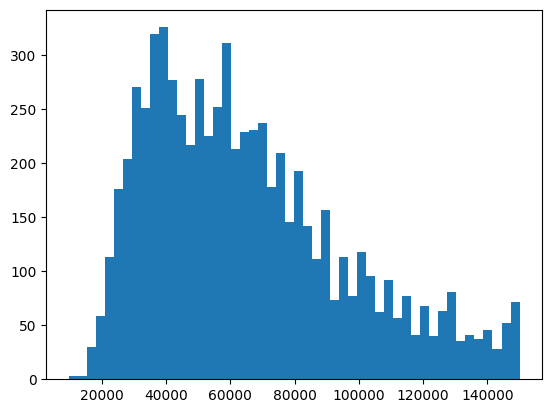

In [56]:
import matplotlib.pyplot as plt

plt.hist(y, bins=50)
plt.show()

In [60]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, lgbm_pred)
print("MAPE:", mape * 100)

MAPE: 14.668188682731085


In [57]:
import pickle
with open('laptop_model.pkl', 'wb') as file:
    pickle.dump(lgbm_pipeline,file)